# Data Cleaning

### Common Data Anomalies

Data quality issues can arise from human errors, system failures or problems during data collection and integration. Some of the most common data quality challenges include:

- Missing values: Incomplete records can reduce statistical power and introduce bias into analysis.
- Duplicate records: Repeated entries may overrepresent certain observations resulting in skewed outcomes.
- Incorrect data types: Mismatched formats, such as text stored in numeric fields can cause calculation errors and analysis failures.
- Outliers and anomalies: Extremely high or low values can distort statistical measures and influence model performance.
- Inconsistent formats: Variations in date formats, text casing or measurement units can create issues when merging or comparing datasets.
- Spelling and typographical errors: Errors in text fields can lead to incorrect grouping, classification or interpretation of categorical data

# Data Cleaning Process

- 1. Assess Data Quality
    - missing values
    - incorrect values
    - inconsistencies in data format
- 2. Remove Irrelevant Data
    - Identify duplicate entries using techniques like sorting, grouping or hashing.
    - Remove duplicate records to ensure each data point is unique and correctly represented.
    - Detect redundant observations that do not add new information to the dataset.
    - Eliminate variables or columns that are irrelevant to the analysis and do not provide useful insights.
- 3. Fix Structural Errors
    - Standardize data formats to maintain consistency in dates, times and other data types across the dataset.
    - Correct naming inconsistencies in column names, variable names or labels to ensure clarity and uniformity.
    - Ensure consistent data representation such as using the same units for measurements or the same scales for ratings.
- 4. Handle Missing Data
    - Impute missing values using statistical methods such as mean, median or mode to fill gaps.
    - Remove records with missing values when the missing data is extensive or cannot be accurately imputed.
    - Apply advanced imputation techniques like regression, k-nearest neighbors or decision trees to estimate missing values.
- 5. Normalize Data
    - Split data into multiple tables, with each table storing specific types of information.
    - Ensure consistency across the dataset to support efficient querying and accurate analysis.
- 6. Identify and Manage Outliers
    - Remove outliers that result from errors or are not representative of the population.
    - Transform extreme but valid outliers to reduce their impact on the analysis.

In [1]:
# Step 1: Import Libraries and Load Dataset
# -----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

df = pd.read_csv('../data/titanic.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Step 2: Check for Duplicate Rows
# --------------------------------
df.duplicated().sum()

np.int64(0)

In [3]:
# Step 3: Identify Column Data Types
# ----------------------------------
num_cols = [col for col in df.columns if df[col].dtype != 'str']
cat_cols = [col for col in df.columns if df[col].dtype == 'str']

print('Categorical columns:', cat_cols)
print('Numerical columns:', num_cols)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [4]:
# Step 4: Count Unique Values in the Categorical Columns
# ------------------------------------------------------
df[cat_cols].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [5]:
# Step 5: Calculate Missing Values as Percentage
# ----------------------------------------------
round((df.isnull().sum() / df.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [6]:
# Step 6: Drop Irrelevant or Data-Heavy Missing Columns
# -----------------------------------------------------

### Drop specified columns from the DataFrame
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

### Remove rows where specified columns have missing values
df = df.dropna(subset=['Embarked'])

###  Fill missing values with specified value
df['Age'] = df['Age'].fillna(df['Age'].mean())

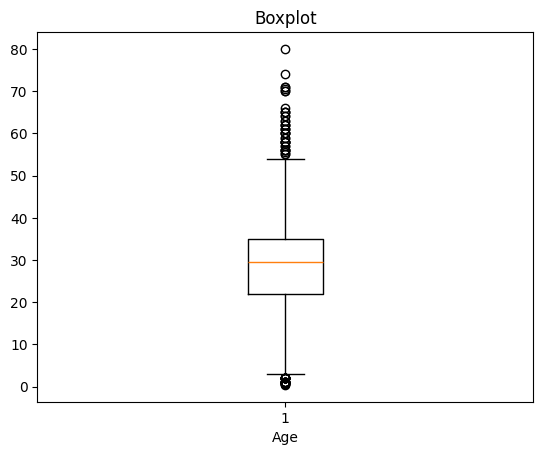

In [7]:
# Step 7: Detect Outliers with Box Plot
# -------------------------------------
plt.boxplot(df['Age'])
plt.xlabel("Age")
plt.title("Boxplot")
plt.show()

In [8]:
# Step 8: Calculate Outlier Boundaries and Remove Them
# ----------------------------------------------------

mean = df['Age'].mean()
std = df['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

In [9]:
# Step 9: Impute Missing Data Again if Any
# ----------------------------------------
df = df.fillna(df['Age'].mean())
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [10]:
# Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data
# -----------------------------------------------------------------------------
mean = df['Age'].mean()
std = df['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df2 = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

Lower Bound : 8.978989004171453
Upper Bound : 49.30395961288914


In [11]:
# Step 11: Data validation and verification
# -----------------------------------------
X = df[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df['Survived']

In [12]:
# Step 12: Data formatting
# ------------------------

### 1. Min-Max Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
num_col_ = [col for col in X.columns if X[col].dtype != 'str']
x1 = X
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S


### Data Cleaning Strategies

Understand the data: Know the source, structure and domain of the data to identify potential quality issues and determine appropriate cleaning actions.

- Document the process: Keep records of decisions, methods, assumptions and rules applied during data cleaning.
- Prioritize critical issues: Focus first on major quality problems that could have a systemic impact on analysis or decision-making.
- Automate where possible: Use scripts or tools for repetitive cleaning tasks to improve efficiency and consistency.
- Collaborate with domain experts: Engage stakeholders or domain specialists to validate that the cleaned data meets business requirements.
- Monitor and maintain: Continuously track data quality and perform cleaning periodically to ensure long-term accuracy and reliability.

### Advantages

- Removing errors, inconsistencies, and irrelevant data helps the model learn better from the data.
- Ensures the data is accurate, consistent, and free of errors.
- Transforms data into a format that better represents underlying patterns and relationships.
- Improves data quality, making it more reliable and accurate.
- Helps identify and remove sensitive or confidential information, improving data security.

### Disadvantages

- It is time-consuming, especially for large and complex datasets.
- It can lead to loss of important information if not handled carefully.
- Requires significant time, effort, expertise, and sometimes specialized tools.
- Removing too much data can contribute to underfitting.